In [16]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('zomato.csv',encoding="latin1")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [17]:
ndf=df.dropna()
ndf.info()

<class 'pandas.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9542 non-null   int64  
 1   Restaurant Name       9542 non-null   str    
 2   Country Code          9542 non-null   int64  
 3   City                  9542 non-null   str    
 4   Address               9542 non-null   str    
 5   Locality              9542 non-null   str    
 6   Locality Verbose      9542 non-null   str    
 7   Longitude             9542 non-null   float64
 8   Latitude              9542 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9542 non-null   int64  
 11  Currency              9542 non-null   str    
 12  Has Table booking     9542 non-null   str    
 13  Has Online delivery   9542 non-null   str    
 14  Is delivering now     9542 non-null   str    
 15  Switch to order menu  9542 non-null  

In [18]:
ndf['Price range']=ndf['Price range'].astype(float)
ndf['Average Cost for two']=ndf['Average Cost for two'].astype(float)

In [19]:
ndf["Cost_Category"] = pd.cut(
    df["Average Cost for two"],
    bins=[0,500,1500,3000,10000],
    labels=["Budget","Mid-range","Expensive","Luxury"]
)

ndf["Rating_Category"] = pd.cut(
    df["Aggregate rating"],
    bins=[0,2.5,3.5,4,5],
    labels=["Poor","Average","Good","Excellent"]
)
ndf.info()


<class 'pandas.DataFrame'>
Index: 9542 entries, 0 to 9550
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Restaurant ID         9542 non-null   int64   
 1   Restaurant Name       9542 non-null   str     
 2   Country Code          9542 non-null   int64   
 3   City                  9542 non-null   str     
 4   Address               9542 non-null   str     
 5   Locality              9542 non-null   str     
 6   Locality Verbose      9542 non-null   str     
 7   Longitude             9542 non-null   float64 
 8   Latitude              9542 non-null   float64 
 9   Cuisines              9542 non-null   str     
 10  Average Cost for two  9542 non-null   float64 
 11  Currency              9542 non-null   str     
 12  Has Table booking     9542 non-null   str     
 13  Has Online delivery   9542 non-null   str     
 14  Is delivering now     9542 non-null   str     
 15  Switch to order menu

In [29]:
print("Total Restaurants:", len(ndf))
print("Average Rating:", ndf['Aggregate rating'].mean())
print("Average Cost for Two:", ndf['Average Cost for two'].mean())

Total Restaurants: 9542
Average Rating: 2.665237895619367
Average Cost for Two: 1200.3261370781806


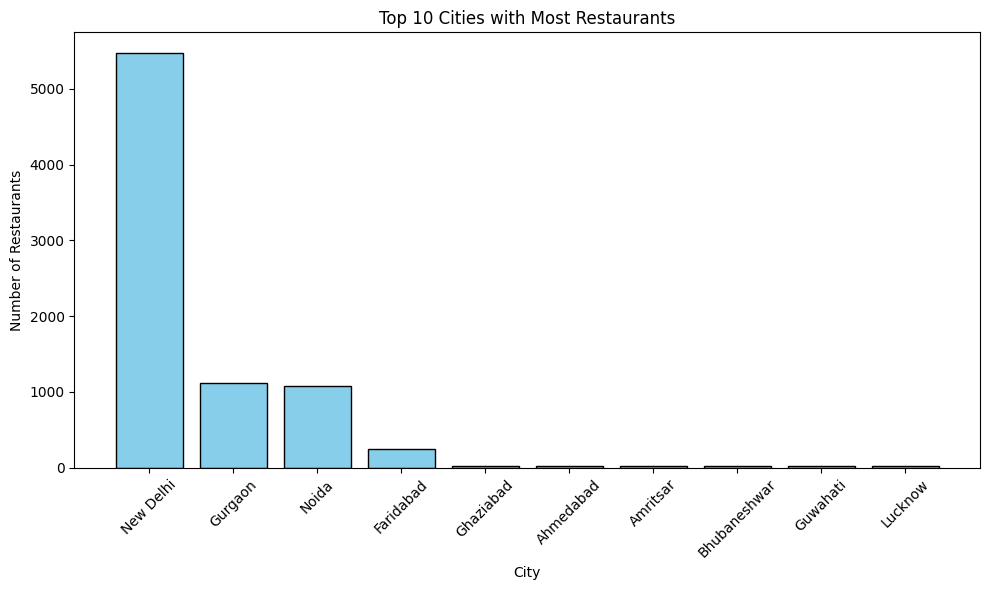

In [20]:
city_counts = ndf['City'].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.bar(city_counts.index, city_counts.values, color='skyblue', edgecolor='black')
plt.title("Top 10 Cities with Most Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_cities_restaurants.png")
plt.show()

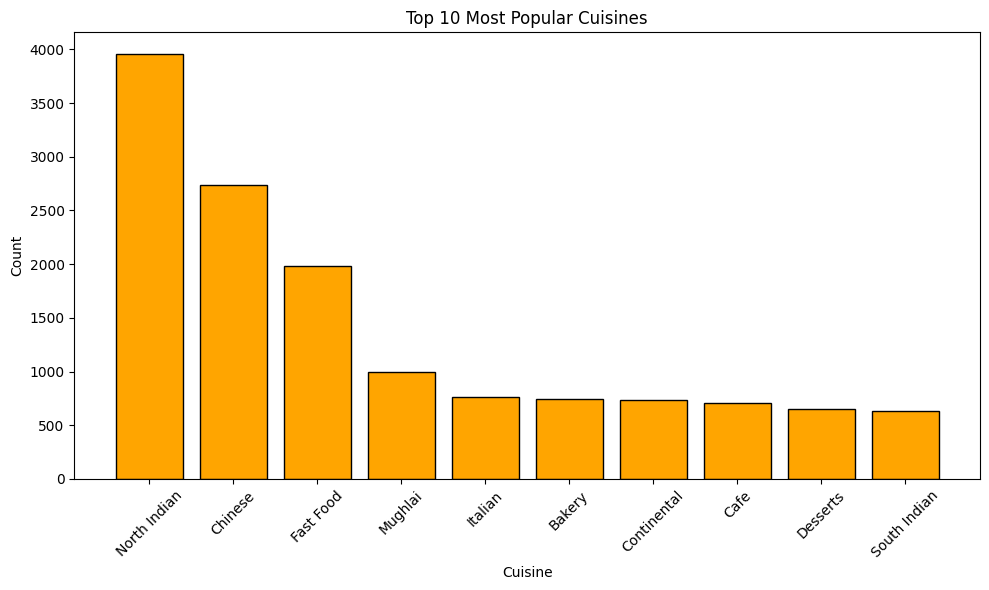

In [21]:
cuisine_series = ndf['Cuisines'].str.split(', ').explode()
top_cuisines = cuisine_series.value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_cuisines.index, top_cuisines.values, color='orange', edgecolor='black')
plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_cuisines.png")
plt.show()

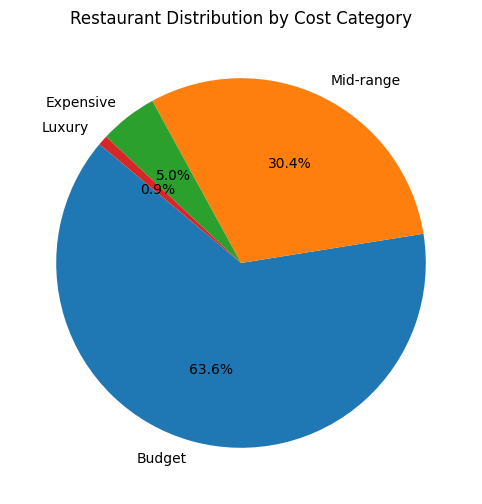

In [22]:
cost_counts = ndf['Cost_Category'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(cost_counts.values,
        labels=cost_counts.index,
        autopct='%1.1f%%',
        startangle=140)
plt.title("Restaurant Distribution by Cost Category")
plt.savefig("cost_category_pie.png")
plt.show()

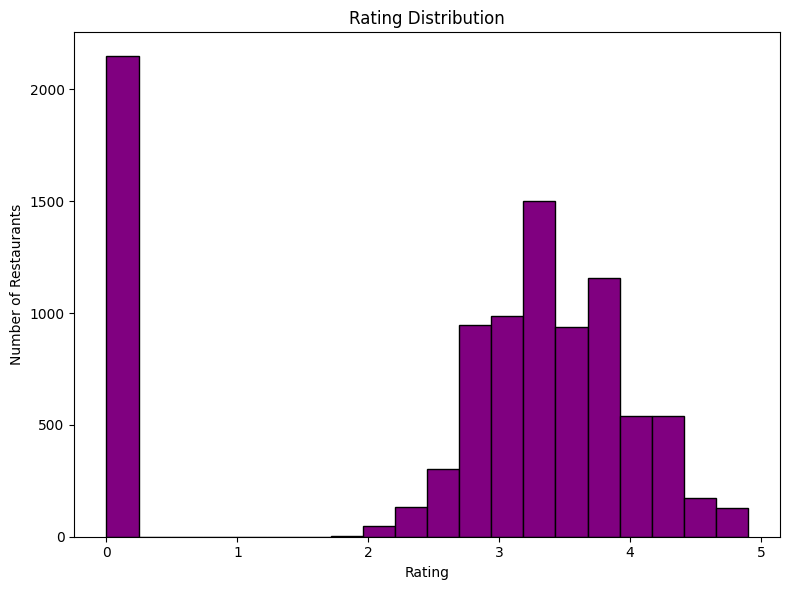

In [23]:
plt.figure(figsize=(8,6))
plt.hist(ndf['Aggregate rating'], bins=20, color='purple', edgecolor='black')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

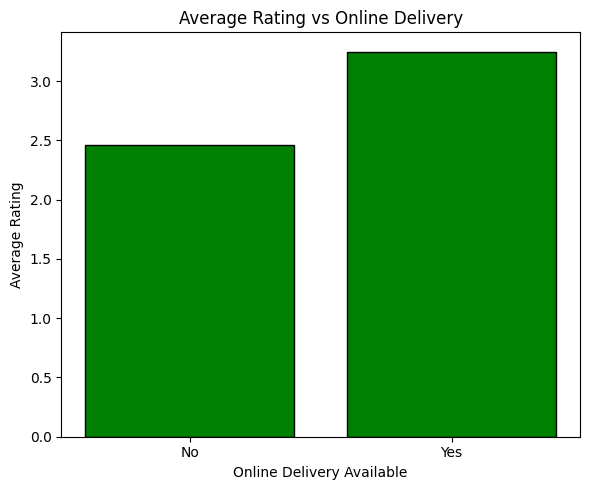

In [24]:
delivery_rating = ndf.groupby('Has Online delivery')['Aggregate rating'].mean()

plt.figure(figsize=(6,5))
plt.bar(delivery_rating.index.astype(str), delivery_rating.values, color='green', edgecolor='black')
plt.title("Average Rating vs Online Delivery")
plt.xlabel("Online Delivery Available")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("online_delivery_rating.png")
plt.show()

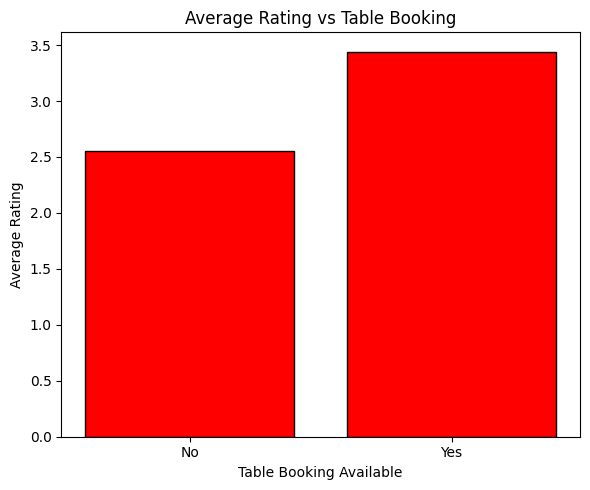

In [25]:
table_rating = ndf.groupby('Has Table booking')['Aggregate rating'].mean()

plt.figure(figsize=(6,5))
plt.bar(table_rating.index.astype(str), table_rating.values, color='red', edgecolor='black')
plt.title("Average Rating vs Table Booking")
plt.xlabel("Table Booking Available")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig("table_booking_rating.png")
plt.show()

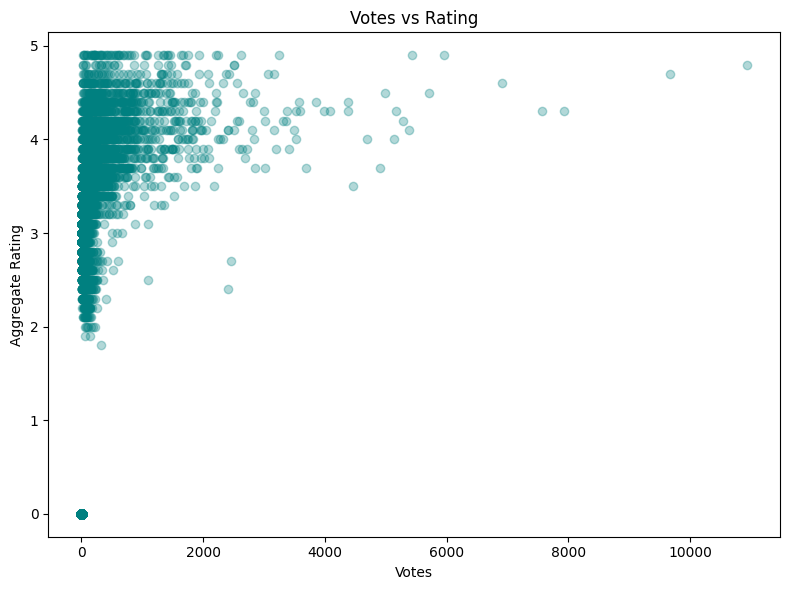

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(ndf['Votes'], ndf['Aggregate rating'], alpha=0.3, color='teal')
plt.title("Votes vs Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.tight_layout()
plt.savefig("votes_vs_rating.png")
plt.show()

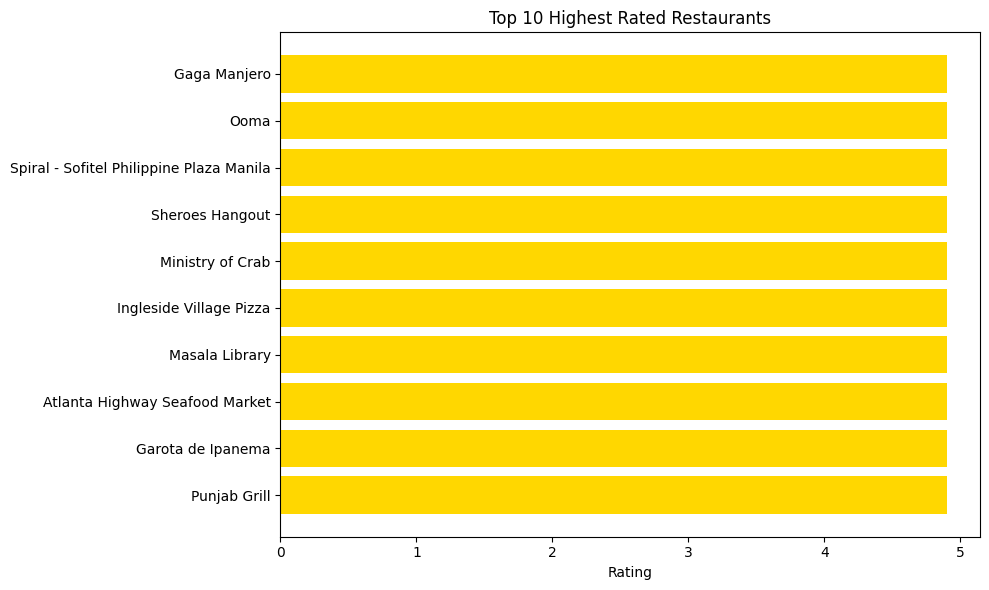

In [27]:
top_rated = ndf.sort_values(by='Aggregate rating', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_rated['Restaurant Name'], top_rated['Aggregate rating'], color='gold')
plt.title("Top 10 Highest Rated Restaurants")
plt.xlabel("Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_rated_restaurants.png")
plt.show()

In [28]:
ndf.to_csv("cleaned_zomato.csv", index=False)

# Final Capstone Report: 3 Actionable Business Insights

Based on the Exploratory Data Analysis of the Zomato dataset, here are three actionable recommendations for restaurant owners and investors:

**1. Invest in Digital Infrastructure (Delivery & Booking)**
The bar charts analyzing `Has Online delivery` and `Has Table booking` clearly show that restaurants offering these digital conveniences maintain higher average aggregate ratings.
* **Action:** New restaurant owners must prioritize partnering with delivery networks and reservation platforms prior to launch to boost their initial customer satisfaction scores.

**2. Customer Engagement Acts as Social Proof**
The `Votes vs Rating` scatter plot reveals a strong positive trend: as the number of votes increases, the aggregate rating heavily clusters in the higher tiers (3.5 to 5.0).
* **Action:** Restaurants should actively incentivize diners to leave reviews (e.g., offering a small complimentary item for a rating). High vote volume acts as social proof and protects the restaurant's average against isolated bad reviews.

**3. Identify "Blue Ocean" Market Opportunities**
The `Cost_Category` pie chart demonstrates that the massive majority of the restaurant market is heavily saturated in the "Budget" tier.
* **Action:** Investors looking to open a new dining establishment should consider targeting the "Mid-range" or "Expensive" categories. Avoiding the hyper-competitive budget segment allows a business to capture a more niche audience with higher profit margins per table.